## Idea from papers

- **Klingler, Käser, Solenthaler & Gross (2016), "Temporally Coherent Clustering of Student Data"**  
  Link: https://files.eric.ed.gov/fulltext/ED592736.pdf  
  Main idea: extracting student behavior is an important task in educational data mining, and clustering can be used to detect similar behavior patterns in student data. Their paper focuses on making clusters temporally coherent, because student behavior evolves over time.  

- **Mejia-Domenzain, Marras, Giang & Käser (2022), "Identifying and Comparing Multi-dimensional Student Profiles Across Flipped Classrooms"**  
Link: https://doi.org/10.1007/978-3-031-11644-5_8  
Main idea: identify multi-dimensional student profiles from learning data and compare these profiles across different classroom contexts.  


In [54]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42

DATA_DIR = Path("data")
OUT_DATASET = DATA_DIR / "stage1.csv.gz"
OUT_CLUSTERS = DATA_DIR / "stage1_clusters.csv.gz"

In [55]:
df = pd.read_csv(OUT_DATASET)

print(df.shape)
print(df.columns.tolist())
df.head()

(22466, 90)
['user_id', 'total_events_0_2', 'n_active_days_0_2', 'n_click_events_0_2', 'n_view_events_0_2', 'n_sessions_0_2', 'n_topics_event_0_2', 'mean_hour_0_2', 'std_hour_0_2', 'total_transactions_0_2', 'correct_rate_0_2', 'partial_rate_0_2', 'mean_evaluation_score_0_2', 'avg_response_time_0_2', 'n_documents_0_2', 'n_topics_transaction_0_2', 'std_evaluation_score_0_2', 'std_response_time_0_2', 'session_duration_mean_0_2', 'session_duration_std_0_2', 'time_between_sessions_mean_0_2', 'retry_ratio_0_2', 'review_rate_0_2', 'study', 'class_year', 'gender_FEMALE', 'gender_MALE', 'gender_Other', 'gender_Unknown', 'canton_AG', 'canton_AI', 'canton_AR', 'canton_Andere', 'canton_BE', 'canton_BL', 'canton_BS', 'canton_FL', 'canton_FR', 'canton_GL', 'canton_GR', 'canton_JU', 'canton_LU', 'canton_NE', 'canton_SG', 'canton_SH', 'canton_SO', 'canton_SZ', 'canton_TG', 'canton_UR', 'canton_Unknown', 'canton_VD', 'canton_VS', 'canton_ZG', 'canton_ZH', 'school_2. Klasse LG', 'school_3. Klasse LG', '

,user_id,total_events_0_2,n_active_days_0_2,n_click_events_0_2,n_view_events_0_2,n_sessions_0_2,n_topics_event_0_2,mean_hour_0_2,std_hour_0_2,total_transactions_0_2,...,school_Passerelle,school_Passerelle BM/FM,school_Sekundarschule P,school_UG,school_Unknown,school_Vorkurs PH für Berufsleute,school_Vorkurs Pädagogik,school_WMS,school_andere,came_back
0,387604,2.0,2.0,0.0,2.0,0.0,0.0,9.000000,5.656854,2,...,0,0,0,0,1,0,0,0,0,1
1,387605,12.0,1.0,7.0,5.0,2.0,2.0,6.000000,0.000000,5,...,0,0,0,0,1,0,0,0,0,1
2,387608,101.0,2.0,35.0,66.0,2.0,1.0,8.603960,1.225391,34,...,0,0,0,0,1,0,0,0,0,1
3,387613,11.0,1.0,3.0,8.0,1.0,1.0,12.000000,0.000000,2,...,0,0,0,0,1,0,0,0,0,1
4,387615,348.0,6.0,76.0,272.0,2.0,1.0,9.784483,2.961246,37,...,0,0,0,0,0,0,0,0,0,1


In [56]:
ID_COL = "user_id"
LABEL_COL = "came_back"

# We remove the ID and the label.
# IMPORTANT: came_back must not be used for clustering.
X = df.drop(columns=[ID_COL, LABEL_COL]).copy()
y = df[LABEL_COL].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (22466, 88)
y shape: (22466,)


,total_events_0_2,n_active_days_0_2,n_click_events_0_2,n_view_events_0_2,n_sessions_0_2,n_topics_event_0_2,mean_hour_0_2,std_hour_0_2,total_transactions_0_2,correct_rate_0_2,...,school_Maturität für Erwachsene,school_Passerelle,school_Passerelle BM/FM,school_Sekundarschule P,school_UG,school_Unknown,school_Vorkurs PH für Berufsleute,school_Vorkurs Pädagogik,school_WMS,school_andere
0,2.0,2.0,0.0,2.0,0.0,0.0,9.000000,5.656854,2,0.000000,...,0,0,0,0,0,1,0,0,0,0
1,12.0,1.0,7.0,5.0,2.0,2.0,6.000000,0.000000,5,0.400000,...,0,0,0,0,0,1,0,0,0,0
2,101.0,2.0,35.0,66.0,2.0,1.0,8.603960,1.225391,34,0.382353,...,0,0,0,0,0,1,0,0,0,0
3,11.0,1.0,3.0,8.0,1.0,1.0,12.000000,0.000000,2,0.500000,...,0,0,0,0,0,1,0,0,0,0
4,348.0,6.0,76.0,272.0,2.0,1.0,9.784483,2.961246,37,0.270270,...,0,0,0,0,0,0,0,0,0,0


In [57]:
numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print("Numerical columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
print(categorical_cols)

Numerical columns: 88
Categorical columns: 0
[]


In [ ]:
preprocess_1 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_processed = preprocess_1.fit_transform(X)

print("Processed shape:", X_processed.shape)

Processed shape: (22466, 88)


In [59]:
silhouette_results = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
    )

    labels = kmeans.fit_predict(X_processed)

    score = silhouette_score(
        X_processed,
        labels,
        sample_size=min(5000, X_processed.shape[0]),
        random_state=RANDOM_STATE,
    )

    silhouette_results.append({
        "k": k,
        "silhouette": score,
    })

    print(f"k={k}, silhouette={score:.4f}")

silhouette_df = pd.DataFrame(silhouette_results)
silhouette_df

k=2, silhouette=0.2259
k=3, silhouette=0.1251
k=4, silhouette=0.0748
k=5, silhouette=0.0720
k=6, silhouette=0.0761
k=7, silhouette=0.0847
k=8, silhouette=0.0823


,k,silhouette
0,2,0.225944
1,3,0.125124
2,4,0.074839
3,5,0.071979
4,6,0.076096
5,7,0.084669
6,8,0.082287


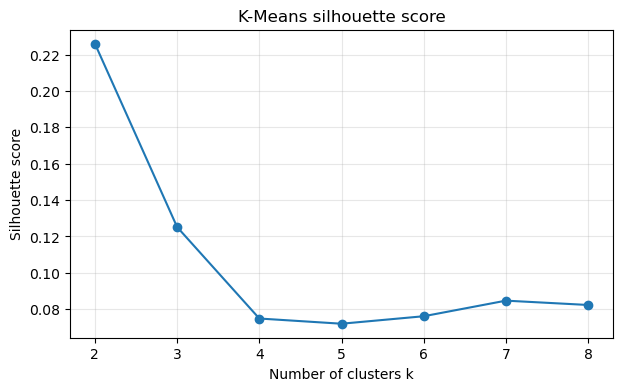

In [60]:
plt.figure(figsize=(7, 4))
plt.plot(silhouette_df["k"], silhouette_df["silhouette"], marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("K-Means silhouette score")
plt.grid(alpha=0.3)
plt.show()

In [61]:
BEST_K = 2

kmeans = KMeans(
    n_clusters=BEST_K,
    random_state=RANDOM_STATE,
    n_init=10,
)

df["cluster"] = kmeans.fit_predict(X_processed)

df["cluster"].value_counts().sort_index()

cluster
0    20296
1     2170
Name: count, dtype: int64

In [62]:
cluster_overview = (
    df.groupby("cluster")
    .agg(
        n_users=("user_id", "count"),
        came_back_rate=("came_back", "mean"),
    )
    .reset_index()
)

cluster_overview["dropout_rate"] = 1 - cluster_overview["came_back_rate"]
cluster_overview["percentage_users"] = cluster_overview["n_users"] / len(df)

cluster_overview.round(3)

,cluster,n_users,came_back_rate,dropout_rate,percentage_users
0,0,20296,0.591,0.409,0.903
1,1,2170,0.762,0.238,0.097


In [63]:
cluster_feature_means = (
    df.groupby("cluster")[numeric_cols]
    .mean()
    .round(3)
)

cluster_feature_means

,total_events_0_2,n_active_days_0_2,n_click_events_0_2,n_view_events_0_2,n_sessions_0_2,n_topics_event_0_2,mean_hour_0_2,std_hour_0_2,total_transactions_0_2,correct_rate_0_2,...,school_Maturität für Erwachsene,school_Passerelle,school_Passerelle BM/FM,school_Sekundarschule P,school_UG,school_Unknown,school_Vorkurs PH für Berufsleute,school_Vorkurs Pädagogik,school_WMS,school_andere
cluster,,,,,,,,,,,,,,,,,,,,,
0,124.414,1.941,47.852,76.562,2.828,1.649,10.827,1.214,25.831,0.272,...,0.000,0.0,0.0,0.0,0.005,0.066,0.001,0.0,0.015,0.013
1,754.074,5.170,317.843,436.231,19.927,7.056,12.378,2.910,164.203,0.333,...,0.002,0.0,0.0,0.0,0.003,0.064,0.003,0.0,0.005,0.011


In [64]:
global_mean = df[numeric_cols].mean()
global_std = df[numeric_cols].std().replace(0, np.nan)

cluster_means = df.groupby("cluster")[numeric_cols].mean()

z_diff = (cluster_means - global_mean) / global_std

for cluster_id in sorted(df["cluster"].unique()):
    print("=" * 80)
    print(f"Cluster {cluster_id}")
    
    print("\nMost above average:")
    print(z_diff.loc[cluster_id].sort_values(ascending=False).head(15))
    
    print("\nMost below average:")
    print(z_diff.loc[cluster_id].sort_values(ascending=True).head(15))

Cluster 0

Most above average:
avg_response_time_0_2        0.021051
class_year                   0.021011
canton_BS                    0.016776
school_FMS                   0.016367
school_Langzeitgymnasium     0.015533
canton_BE                    0.015379
canton_ZH                    0.014429
gender_MALE                  0.008779
school_WMS                   0.008313
study                        0.006725
session_duration_mean_0_2    0.005464
canton_LU                    0.005462
school_5. Klasse LG          0.004682
canton_FR                    0.004578
school_6. Klasse LG          0.004065
Name: 0, dtype: float64

Most below average:
total_events_0_2            -0.241133
n_view_events_0_2           -0.237021
n_click_events_0_2          -0.234708
n_documents_0_2             -0.234497
total_transactions_0_2      -0.231063
n_sessions_0_2              -0.219050
n_topics_transaction_0_2    -0.200733
n_topics_event_0_2          -0.200407
n_active_days_0_2           -0.169007
std_hour_0_2

### Interpretation

For `k=2`, K-Means mainly separates users according to their early activity level.

Cluster 0 contains the large majority of users, around 90.3% of the dataset. This cluster is below average on almost all activity-related features: number of events, views, clicks, documents, transactions, sessions, topics, and active days. Therefore, we interpret it as a **low early activity** cluster. Its continuation rate is 0.591, corresponding to an early dropout rate of 0.409.

Cluster 1 is much smaller, around 9.7% of users, but it is strongly above average on all main engagement features. These users have many more events, views, clicks, documents, transactions, sessions, topics, and active days during the first weeks. We interpret it as a **high early activity** cluster. Its continuation rate is 0.762, corresponding to a much lower early dropout rate of 0.238.

Importantly, the `came_back` label was not used to create the clusters. The difference in dropout rate therefore suggests that early activity intensity naturally separates users with different probabilities of returning to the platform.

In [65]:
BEST_K = 4

kmeans4 = KMeans(
    n_clusters=BEST_K,
    random_state=RANDOM_STATE,
    n_init=10,
)

df["cluster_k4"] = kmeans4.fit_predict(X_processed)

df["cluster_k4"].value_counts().sort_index()

cluster_k4
0     7344
1     1443
2    11926
3     1753
Name: count, dtype: int64

In [66]:
cluster_k4_overview = (
    df.groupby("cluster_k4")
    .agg(
        n_users=("user_id", "count"),
        came_back_rate=("came_back", "mean"),
    )
    .reset_index()
)

cluster_k4_overview["dropout_rate"] = 1 - cluster_k4_overview["came_back_rate"]
cluster_k4_overview["percentage_users"] = cluster_k4_overview["n_users"] / len(df)

cluster_k4_overview.round(3)

,cluster_k4,n_users,came_back_rate,dropout_rate,percentage_users
0,0,7344,0.568,0.432,0.327
1,1,1443,0.594,0.406,0.064
2,2,11926,0.610,0.390,0.531
3,3,1753,0.771,0.229,0.078


In [67]:
global_mean = df[numeric_cols].mean()
global_std = df[numeric_cols].std().replace(0, np.nan)

cluster_means_k4 = df.groupby("cluster_k4")[numeric_cols].mean()
z_diff_k4 = (cluster_means_k4 - global_mean) / global_std

for cluster_id in sorted(df["cluster_k4"].unique()):
    print("=" * 80)
    print(f"Cluster {cluster_id}")
    
    print("\nMost above average:")
    print(z_diff_k4.loc[cluster_id].sort_values(ascending=False).head(15))
    
    print("\nMost below average:")
    print(z_diff_k4.loc[cluster_id].sort_values(ascending=True).head(15))

Cluster 0

Most above average:
canton_ZH                    1.045248
school_Kurzzeitgymnasium     0.775603
school_Langzeitgymnasium     0.739094
canton_AG                    0.537328
class_year                   0.411161
school_KME Teilzeit          0.191663
canton_LU                    0.163368
school_KME Vollzeit          0.158988
school_HMS                   0.125520
gender_MALE                  0.122028
school_Liceo Artistico       0.107501
mean_evaluation_score_0_2    0.095204
school_KME Passerelle        0.091640
correct_rate_0_2             0.089083
std_evaluation_score_0_2     0.075439
Name: 0, dtype: float64

Most below average:
school_Gymnasium           -0.851821
canton_SG                  -0.477046
canton_BL                  -0.297076
canton_SO                  -0.290911
canton_Unknown             -0.265364
school_Unknown             -0.265364
canton_BS                  -0.264883
gender_Unknown             -0.264594
canton_BE                  -0.262179
school_FMS           

### Interpretation of k=4 with all features

Although `k=2` gives the best silhouette score, we also inspect `k=4` to see whether more fine-grained learner profiles appear.

The result shows that the 4-cluster solution is partly dominated by demographic and school-related variables.

- **Cluster 0** is mostly characterized by `canton_ZH`, `canton_AG`, `school_Kurzzeitgymnasium`, `school_Langzeitgymnasium`, and `class_year`. Its dropout rate is 43.2%. This cluster is therefore not mainly a behavioral learner profile, but rather a school/canton-driven group.

- **Cluster 1** is strongly characterized by missing demographic values: `school_Unknown`, `canton_Unknown`, and `gender_Unknown`. Its dropout rate is 40.6%. This suggests that missing metadata itself creates a separate cluster.

- **Cluster 2** is characterized by `school_Gymnasium`, `canton_SG`, `canton_BS`, `canton_SO`, `canton_BL`, and `canton_BE`, while also being below average on activity features such as documents, events, transactions, sessions, and topics. Its dropout rate is 39.0%.

- **Cluster 3** is the only clearly behavioral high-engagement cluster. It is strongly above average on events, clicks, views, documents, transactions, sessions, topics, and active days. It has the lowest dropout rate, 22.9%.

This analysis suggests that clustering with all features mixes two effects: demographic/school structure and actual learning behavior. Since our goal is to identify behavioral learner profiles, we next remove demographic and school-related variables and repeat the clustering using only early behavioral features.

In [68]:
important_features = [
    "total_events_0_2",
    "n_active_days_0_2",
    "n_click_events_0_2",
    "n_view_events_0_2",
    "n_sessions_0_2",
    "n_topics_event_0_2",
    "total_transactions_0_2",
    "correct_rate_0_2",
    "wrong_rate_0_2",
    "partial_rate_0_2",
    "skip_rate_0_2",
    "retry_ratio_0_2",
    "avg_response_time_0_2",
    "session_duration_mean_0_2",
]

important_features = [c for c in important_features if c in df.columns]

df.groupby("cluster_k4")[important_features + ["came_back"]].mean().round(3)

,total_events_0_2,n_active_days_0_2,n_click_events_0_2,n_view_events_0_2,n_sessions_0_2,n_topics_event_0_2,total_transactions_0_2,correct_rate_0_2,partial_rate_0_2,retry_ratio_0_2,avg_response_time_0_2,session_duration_mean_0_2,came_back
cluster_k4,,,,,,,,,,,,,
0,140.034,1.961,54.989,85.045,2.932,1.652,30.384,0.296,0.247,1.415,90.308,32831.004,0.568
1,147.055,2.217,49.545,97.510,3.953,2.362,28.421,0.260,0.131,1.357,51.887,49767.836,0.594
2,124.250,1.976,47.846,76.404,2.921,1.687,25.387,0.260,0.249,1.363,95.120,49378.277,0.610
3,820.896,5.394,350.816,470.080,21.998,7.484,178.938,0.339,0.278,1.660,70.845,30240.796,0.771


This table summarizes the main behavioral features for the `k=4` all-feature clustering. It confirms that Cluster 3 is the only clearly high-engagement cluster: 

Users in this cluster have far more events, sessions, transactions, active days, topics, clicks, and views than the other clusters. 

This cluster also has the highest continuation rate (`came_back = 0.771`). In contrast, Clusters 0, 1, and 2 have similar low-to-medium activity levels and are more clearly distinguished by demographic or school-related variables, as shown by the previous standardized feature differences.

In [69]:
demo_prefixes = [
    "gender_",
    "canton_",
    "school_",
]

extra_demo_cols = [
    "class_year",
    "study",
]

demo_cols = [
    c for c in df.columns
    if any(c.startswith(prefix) for prefix in demo_prefixes)
]

demo_cols += [c for c in extra_demo_cols if c in df.columns]
demo_cols = sorted(set(demo_cols))

print("Demographic columns removed:", len(demo_cols))
print(demo_cols)

Demographic columns removed: 66
['canton_AG', 'canton_AI', 'canton_AR', 'canton_Andere', 'canton_BE', 'canton_BL', 'canton_BS', 'canton_FL', 'canton_FR', 'canton_GL', 'canton_GR', 'canton_JU', 'canton_LU', 'canton_NE', 'canton_SG', 'canton_SH', 'canton_SO', 'canton_SZ', 'canton_TG', 'canton_UR', 'canton_Unknown', 'canton_VD', 'canton_VS', 'canton_ZG', 'canton_ZH', 'class_year', 'gender_FEMALE', 'gender_MALE', 'gender_Other', 'gender_Unknown', 'school_2. Klasse LG', 'school_3. Klasse LG', 'school_4. Klasse LG', 'school_5. Klasse LG', 'school_6. Klasse LG', 'school_7. Klasse LG', 'school_BME', 'school_BME (Matura)', 'school_FM', 'school_FM (Fachmaturität)', 'school_FMS', 'school_Fachmaturität Pädagogik', 'school_Gymnasium', 'school_HMS', 'school_IMS', 'school_ISME', 'school_ISME (Matura)', 'school_K+S', 'school_KME Passerelle', 'school_KME Teilzeit', 'school_KME Vollzeit', 'school_Keine Angabe', 'school_Kurzzeitgymnasium', 'school_Langzeitgymnasium', 'school_Liceo Artistico', 'school_Mat

In [70]:
cols_to_drop = [
    "user_id",
    "came_back",
    "cluster",
    "cluster_k4",
    "cluster_gmm",
    "cluster_name",
]

X_behav = df.drop(
    columns=cols_to_drop + demo_cols,
    errors="ignore"
).copy()

print("Behavior-only features:", X_behav.shape[1])
X_behav.head()

Behavior-only features: 22


,total_events_0_2,n_active_days_0_2,n_click_events_0_2,n_view_events_0_2,n_sessions_0_2,n_topics_event_0_2,mean_hour_0_2,std_hour_0_2,total_transactions_0_2,correct_rate_0_2,...,avg_response_time_0_2,n_documents_0_2,n_topics_transaction_0_2,std_evaluation_score_0_2,std_response_time_0_2,session_duration_mean_0_2,session_duration_std_0_2,time_between_sessions_mean_0_2,retry_ratio_0_2,review_rate_0_2
0,2.0,2.0,0.0,2.0,0.0,0.0,9.000000,5.656854,2,0.000000,...,0.000000,1,0,0.000000,0.000000,0.0000,0.000000,0.000,2.000000,0.000000
1,12.0,1.0,7.0,5.0,2.0,2.0,6.000000,0.000000,5,0.400000,...,39.957000,5,2,0.500000,8.813259,67.9890,91.349711,11.093,1.000000,0.000000
2,101.0,2.0,35.0,66.0,2.0,1.0,8.603960,1.225391,34,0.382353,...,26.930133,15,1,0.484152,17.598100,268.7685,140.867692,213.765,2.266667,1.000000
3,11.0,1.0,3.0,8.0,1.0,1.0,12.000000,0.000000,2,0.500000,...,24.976000,2,1,0.707107,0.000000,40.1110,0.000000,0.000,1.000000,2.000000
4,348.0,6.0,76.0,272.0,2.0,1.0,9.784483,2.961246,37,0.270270,...,46.730929,19,1,0.446458,47.616260,428.2360,176.792252,14.439,1.947368,1.428571


In [71]:
preprocess_behav = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_behav_processed = preprocess_behav.fit_transform(X_behav)

print(X_behav_processed.shape)

(22466, 22)


In [72]:
silhouette_behav_results = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
    )

    labels = kmeans.fit_predict(X_behav_processed)

    score = silhouette_score(
        X_behav_processed,
        labels,
        sample_size=min(5000, X_behav_processed.shape[0]),
        random_state=RANDOM_STATE,
    )

    silhouette_behav_results.append({
        "k": k,
        "silhouette": score,
    })

    print(f"k={k}, silhouette={score:.4f}")

silhouette_behav_df = pd.DataFrame(silhouette_behav_results)
silhouette_behav_df

k=2, silhouette=0.4077
k=3, silhouette=0.1695
k=4, silhouette=0.1660
k=5, silhouette=0.1851
k=6, silhouette=0.1480
k=7, silhouette=0.1508
k=8, silhouette=0.1454


,k,silhouette
0,2,0.407662
1,3,0.169527
2,4,0.166007
3,5,0.185127
4,6,0.148046
5,7,0.150758
6,8,0.145426


In [73]:
kmeans_behav_k2 = KMeans(
    n_clusters=2,
    random_state=RANDOM_STATE,
    n_init=10,
)

df["cluster_behav_k2"] = kmeans_behav_k2.fit_predict(X_behav_processed)

df["cluster_behav_k2"].value_counts().sort_index()

cluster_behav_k2
0    20288
1     2178
Name: count, dtype: int64

In [74]:
cluster_behav_k2_overview = (
    df.groupby("cluster_behav_k2")
    .agg(
        n_users=("user_id", "count"),
        came_back_rate=("came_back", "mean"),
    )
    .reset_index()
)

cluster_behav_k2_overview["dropout_rate"] = 1 - cluster_behav_k2_overview["came_back_rate"]
cluster_behav_k2_overview["percentage_users"] = cluster_behav_k2_overview["n_users"] / len(df)

cluster_behav_k2_overview.round(3)

,cluster_behav_k2,n_users,came_back_rate,dropout_rate,percentage_users
0,0,20288,0.591,0.409,0.903
1,1,2178,0.758,0.242,0.097


In [75]:
df.groupby("cluster_behav_k2")[important_features + ["came_back"]].mean().round(3)

,total_events_0_2,n_active_days_0_2,n_click_events_0_2,n_view_events_0_2,n_sessions_0_2,n_topics_event_0_2,total_transactions_0_2,correct_rate_0_2,partial_rate_0_2,retry_ratio_0_2,avg_response_time_0_2,session_duration_mean_0_2,came_back
cluster_behav_k2,,,,,,,,,,,,,
0,124.288,1.941,47.826,76.461,2.821,1.646,25.794,0.272,0.241,1.372,90.836,43313.462,0.591
1,752.937,5.159,317.090,435.848,19.927,7.069,164.043,0.331,0.266,1.687,70.617,34931.044,0.758


In [76]:
behav_numeric_cols = X_behav.columns.tolist()

global_mean_behav = df[behav_numeric_cols].mean()
global_std_behav = df[behav_numeric_cols].std().replace(0, np.nan)

cluster_means_behav_k2 = df.groupby("cluster_behav_k2")[behav_numeric_cols].mean()
z_diff_behav_k2 = (cluster_means_behav_k2 - global_mean_behav) / global_std_behav

for cluster_id in sorted(df["cluster_behav_k2"].unique()):
    print("=" * 80)
    print(f"Cluster {cluster_id}")
    
    print("\nMost above average:")
    print(z_diff_behav_k2.loc[cluster_id].sort_values(ascending=False).head(15))
    
    print("\nMost below average:")
    print(z_diff_behav_k2.loc[cluster_id].sort_values(ascending=True).head(15))

Cluster 0

Most above average:
avg_response_time_0_2             0.020847
session_duration_mean_0_2         0.005451
review_rate_0_2                   0.003142
partial_rate_0_2                 -0.011948
time_between_sessions_mean_0_2   -0.013747
std_response_time_0_2            -0.024425
correct_rate_0_2                 -0.028657
session_duration_std_0_2         -0.028742
std_evaluation_score_0_2         -0.030339
mean_evaluation_score_0_2        -0.033763
retry_ratio_0_2                  -0.046203
mean_hour_0_2                    -0.048405
std_hour_0_2                     -0.109905
n_active_days_0_2                -0.169046
n_topics_event_0_2               -0.201784
Name: 0, dtype: float64

Most below average:
total_events_0_2            -0.241634
n_view_events_0_2           -0.237708
n_click_events_0_2          -0.234938
n_documents_0_2             -0.234300
total_transactions_0_2      -0.231710
n_sessions_0_2              -0.219942
n_topics_transaction_0_2    -0.202096
n_topics_even

### Interpretation of behavior-only k=2 clustering

After removing demographic and school-related variables, the behavior-only clustering gives a clear two-cluster structure.

- **Cluster 0: Low early activity users**  
  This cluster contains 20,288 users, or 90.3% of the dataset. It is below average on almost all activity-related features: total events, views, clicks, documents, transactions, sessions, topics, and active days. Its continuation rate is 0.591, corresponding to an early dropout rate of 0.409.

- **Cluster 1: High early activity users**  
  This cluster contains 2,178 users, or 9.7% of the dataset. It is strongly above average on the main engagement features: total events, views, clicks, documents, transactions, sessions, topics, and active days. Its continuation rate is 0.758, corresponding to a much lower early dropout rate of 0.242.

The `came_back` label was not used to create the clusters. It is only used after clustering to interpret the profiles. Therefore, the difference in dropout rate suggests that early activity intensity naturally separates users with different continuation behavior.

high early activity profile ↔ lower dropout rate


low early activity profile ↔ higher dropout rate

## Multi-dimensional learner profiles

The previous clustering shows that the cleanest behavior-only separation is between low early activity and high early activity users.

To make the interpretation closer to multi-dimensional student profiling work, we now summarize each cluster along several interpretable behavioral dimensions:

- **Activity**: how much the user interacts with the platform.
- **Regularity**: how regularly the user comes back during the observation window.
- **Performance**: how well the user answers questions.
- **Persistence**: how much effort or repeated interaction the user shows.
- **Breadth**: how many topics the user explores.

The goal is not to create new clusters here, but to better describe the clusters we already found.

In [77]:
feature_groups = {
    "activity": [
        "total_events_0_2",
        "n_click_events_0_2",
        "n_view_events_0_2",
        "total_transactions_0_2",
        "n_documents_0_2",
    ],
    "regularity": [
        "n_active_days_0_2",
        "n_sessions_0_2",
        "time_between_sessions_mean_0_2",
        "mean_hour_0_2",
        "std_hour_0_2",
    ],
    "performance": [
        "correct_rate_0_2",
        "partial_rate_0_2",
        "mean_evaluation_score_0_2",
        "std_evaluation_score_0_2",
    ],
    "persistence": [
        "retry_ratio_0_2",
        "review_rate_0_2",
        "avg_response_time_0_2",
        "std_response_time_0_2",
        "session_duration_mean_0_2",
        "session_duration_std_0_2",
    ],
    "breadth": [
        "n_topics_event_0_2",
        "n_topics_transaction_0_2",
    ],
}

# Keep only columns that exist in the dataframe
feature_groups = {
    group_name: [c for c in cols if c in df.columns]
    for group_name, cols in feature_groups.items()
}

feature_groups

{'activity': ['total_events_0_2',
  'n_click_events_0_2',
  'n_view_events_0_2',
  'total_transactions_0_2',
  'n_documents_0_2'],
 'regularity': ['n_active_days_0_2',
  'n_sessions_0_2',
  'time_between_sessions_mean_0_2',
  'mean_hour_0_2',
  'std_hour_0_2'],
 'performance': ['correct_rate_0_2',
  'partial_rate_0_2',
  'mean_evaluation_score_0_2',
  'std_evaluation_score_0_2'],
 'persistence': ['retry_ratio_0_2',
  'review_rate_0_2',
  'avg_response_time_0_2',
  'std_response_time_0_2',
  'session_duration_mean_0_2',
  'session_duration_std_0_2'],
 'breadth': ['n_topics_event_0_2', 'n_topics_transaction_0_2']}

In [88]:
dimension_scores = pd.DataFrame(index=df.index)

for group_name, cols in feature_groups.items():
    X_group = df[cols].copy()

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    X_group_scaled = pipe.fit_transform(X_group)

    dimension_scores[group_name] = X_group_scaled.mean(axis=1)

dimension_scores["user_id"] = df["user_id"]
dimension_scores["came_back"] = df["came_back"]
dimension_scores["cluster_behav_k2"] = df["cluster_behav_k2"]

dimension_scores.head()

,activity,regularity,performance,persistence,breadth,user_id,came_back,cluster_behav_k2
0,-0.704494,0.248437,-1.767382,-0.385423,-0.832549,387604,1,0
1,-0.646267,-0.750884,0.469801,-0.554719,-0.063948,387605,1,0
2,-0.283704,-0.312771,0.140796,-0.143174,-0.448248,387608,1,0
3,-0.677962,-0.394089,0.717797,-0.387882,-0.448248,387613,1,0
4,0.300662,0.426684,-0.163334,-0.103449,-0.448248,387615,1,0


In [89]:
profile_summary_k2 = (
    dimension_scores
    .groupby("cluster_behav_k2")
    .agg(
        n_users=("user_id", "count"),
        continuation_rate=("came_back", "mean"),
        activity=("activity", "mean"),
        regularity=("regularity", "mean"),
        performance=("performance", "mean"),
        persistence=("persistence", "mean"),
        breadth=("breadth", "mean"),
    )
)

profile_summary_k2["early_dropout_rate"] = 1 - profile_summary_k2["continuation_rate"]

profile_summary_k2.round(3)

,n_users,continuation_rate,activity,regularity,performance,persistence,breadth,early_dropout_rate
cluster_behav_k2,,,,,,,,
0,20288,0.591,-0.236,-0.112,-0.026,-0.012,-0.202,0.409
1,2178,0.758,2.199,1.045,0.244,0.109,1.881,0.242


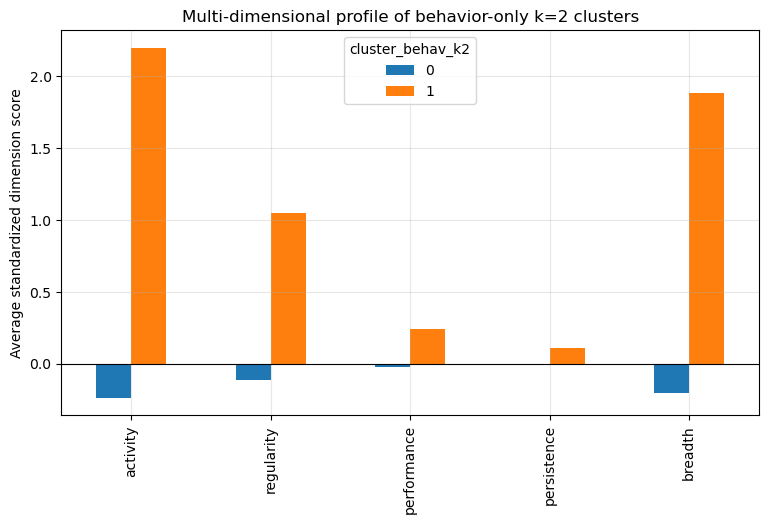

In [91]:
profile_dims = ["activity", "regularity", "performance", "persistence", "breadth"]

profile_summary_k2[profile_dims].T.plot(kind="bar", figsize=(9, 5))

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Average standardized dimension score")
plt.title("Multi-dimensional profile of behavior-only k=2 clusters")
plt.grid(alpha=0.3)
plt.show()

### Interpretation of multi-dimensional profiles

The multi-dimensional profile confirms that the behavior-only `k=2` clustering mainly separates users by early engagement intensity.

Cluster 0 contains most users and has slightly below-average scores on activity, regularity, performance, persistence, and breadth. This means that these users interact less with the platform, use fewer sessions, explore fewer topics, and show weaker early engagement overall. This cluster has a continuation rate of 0.591, corresponding to an early dropout rate of 0.409.

Cluster 1 is much smaller but has strongly above-average scores on activity, regularity, and breadth. These users interact much more with Lernnavi, are active across more sessions/days, and explore more topics during the first weeks. It also has slightly higher performance and persistence scores. This cluster has a continuation rate of 0.758, corresponding to a lower early dropout rate of 0.242.

Overall, this suggests that the main behavioral difference between early users is not only the amount of activity, but also the breadth and regularity of their engagement. High early engagement is associated with a substantially lower early dropout rate.

## Exploratory behavior-only clustering with k=5

The behavior-only `k=2` solution gives the clearest separation, but it is highly imbalanced and mainly distinguishes a small highly engaged group from the large mass of low-activity users.

To obtain more fine-grained behavioral profiles, we also inspect a `k=5` solution. This is exploratory: the silhouette score is lower than for `k=2`, so we use it mainly for interpretation rather than as the main clustering result.

In [93]:
kmeans_behav_k5 = KMeans(
    n_clusters=5,
    random_state=RANDOM_STATE,
    n_init=10,
)

df["cluster_behav_k5"] = kmeans_behav_k5.fit_predict(X_behav_processed)

df["cluster_behav_k5"].value_counts().sort_index()

cluster_behav_k5
0    12248
1      497
2     3874
3     1454
4     4393
Name: count, dtype: int64

In [94]:
cluster_behav_k5_overview = (
    df.groupby("cluster_behav_k5")
    .agg(
        n_users=("user_id", "count"),
        continuation_rate=("came_back", "mean"),
    )
    .reset_index()
)

cluster_behav_k5_overview["early_dropout_rate"] = 1 - cluster_behav_k5_overview["continuation_rate"]
cluster_behav_k5_overview["percentage_users"] = cluster_behav_k5_overview["n_users"] / len(df)

cluster_behav_k5_overview.round(3)

,cluster_behav_k5,n_users,continuation_rate,early_dropout_rate,percentage_users
0,0,12248,0.572,0.428,0.545
1,1,497,0.797,0.203,0.022
2,2,3874,0.708,0.292,0.172
3,3,1454,0.735,0.265,0.065
4,4,4393,0.555,0.445,0.196


In [95]:
df.groupby("cluster_behav_k5")[important_features + ["came_back"]].mean().round(3)

,total_events_0_2,n_active_days_0_2,n_click_events_0_2,n_view_events_0_2,n_sessions_0_2,n_topics_event_0_2,total_transactions_0_2,correct_rate_0_2,partial_rate_0_2,retry_ratio_0_2,avg_response_time_0_2,session_duration_mean_0_2,came_back
cluster_behav_k5,,,,,,,,,,,,,
0,111.325,1.663,44.283,67.042,2.359,1.421,23.812,0.360,0.246,1.330,102.090,9083.472,0.572
1,1357.857,6.905,594.887,762.970,38.046,10.831,293.123,0.351,0.263,1.769,65.721,17898.637,0.797
2,425.388,3.952,171.468,253.920,10.665,4.680,92.584,0.311,0.260,1.638,75.802,33216.922,0.708
3,165.339,3.293,58.035,107.304,3.557,2.180,29.620,0.248,0.275,1.371,113.048,455975.367,0.735
4,53.433,1.531,16.899,36.534,1.444,1.069,9.453,0.022,0.208,1.368,58.184,9788.938,0.555


In [96]:
dimension_scores["cluster_behav_k5"] = df["cluster_behav_k5"]

profile_summary_k5 = (
    dimension_scores
    .groupby("cluster_behav_k5")
    .agg(
        n_users=("user_id", "count"),
        continuation_rate=("came_back", "mean"),
        activity=("activity", "mean"),
        regularity=("regularity", "mean"),
        performance=("performance", "mean"),
        persistence=("persistence", "mean"),
        breadth=("breadth", "mean"),
    )
)

profile_summary_k5["early_dropout_rate"] = 1 - profile_summary_k5["continuation_rate"]

profile_summary_k5.round(3)

,n_users,continuation_rate,activity,regularity,performance,persistence,breadth,early_dropout_rate
cluster_behav_k5,,,,,,,,
0,12248,0.572,-0.276,-0.211,0.313,-0.078,-0.288,0.428
1,497,0.797,4.477,1.770,0.293,0.063,3.324,0.203
2,3874,0.708,0.940,0.654,0.181,0.084,0.963,0.292
3,1454,0.735,-0.113,0.153,0.013,1.070,0.002,0.265
4,4393,0.555,-0.528,-0.240,-1.068,-0.219,-0.423,0.445


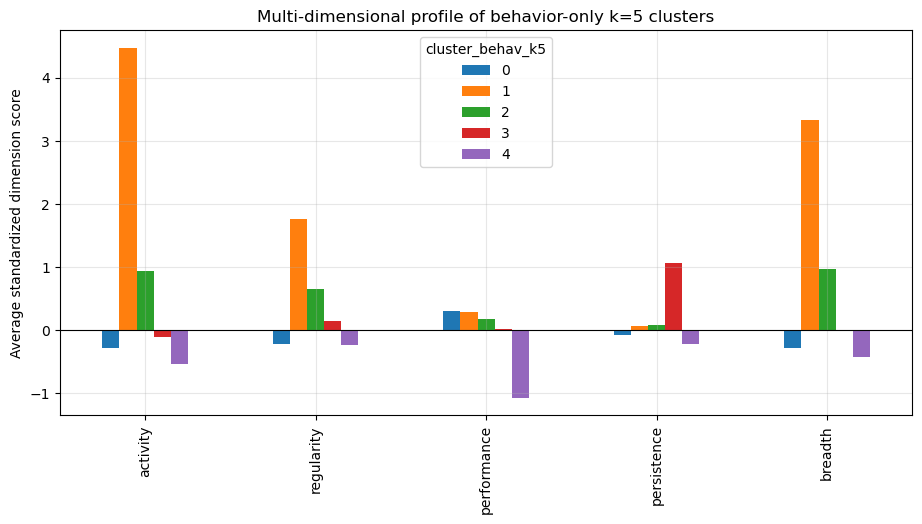

In [97]:
profile_dims = ["activity", "regularity", "performance", "persistence", "breadth"]

profile_plot_k5 = profile_summary_k5[profile_dims].copy()

profile_plot_k5.T.plot(kind="bar", figsize=(11, 5))

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Average standardized dimension score")
plt.title("Multi-dimensional profile of behavior-only k=5 clusters")
plt.grid(alpha=0.3)
plt.show()

### Interpretation of behavior-only k=5 profiles

The `k=5` solution gives a more fine-grained view of early learner behavior. Unlike the `k=2` solution, which mainly separates low-activity and high-activity users, `k=5` reveals several subprofiles.

- **Cluster 0: Low activity but decent performance**  
  This is the largest group. These users are below average in activity, regularity, and breadth, but above average in performance. Their early dropout rate is 42.8%.

- **Cluster 1: Highly engaged broad users**  
  This is a small but very active group. Users are extremely above average in activity, regularity, and breadth. They have the lowest early dropout rate, 20.3%.

- **Cluster 2: Moderately engaged users**  
  These users are above average in activity, regularity, performance, and breadth, but less extreme than Cluster 1. Their early dropout rate is 29.2%.

- **Cluster 3: Persistent focused users**  
  These users are not especially high in overall activity or breadth, but they show high persistence. Their early dropout rate is 26.5%, suggesting that persistence may be associated with continuation even without very broad activity.

- **Cluster 4: Low activity struggling users**  
  These users are below average on almost all dimensions, especially performance. They have the highest early dropout rate, 44.5%.

Overall, the `k=5` solution suggests that early dropout is not only related to activity quantity. Performance, persistence, and breadth help distinguish different types of low- and medium-activity users. However, since the silhouette score for `k=5` is lower than for `k=2`, we treat this analysis as exploratory.

Since the silhouette score for `k=5` is lower than for `k=2`, we treat the five-profile solution as exploratory rather than as the main clustering result.

To check whether the profiles are specific to K-Means or appear with other clustering assumptions, we compare K-Means with Gaussian Mixture Models and Agglomerative Clustering on the behavior-only feature space.

## Alternative clustering method: Gaussian Mixture Model

K-Means assigns each user to a single cluster and assumes roughly spherical clusters. 

As an alternative, we test a Gaussian Mixture Model (GMM), which gives a probabilistic clustering. 

This can be useful because learner profiles may overlap rather than form perfectly separated groups.

In [99]:
from sklearn.mixture import GaussianMixture

gmm_k5 = GaussianMixture(
    n_components=5,
    random_state=RANDOM_STATE,
    covariance_type="full",
)

df["cluster_gmm_k5"] = gmm_k5.fit_predict(X_behav_processed)

df["cluster_gmm_k5"].value_counts().sort_index()

cluster_gmm_k5
0    10807
1     1128
2     6283
3     1737
4     2511
Name: count, dtype: int64

In [100]:
cluster_gmm_k5_overview = (
    df.groupby("cluster_gmm_k5")
    .agg(
        n_users=("user_id", "count"),
        continuation_rate=("came_back", "mean"),
    )
    .reset_index()
)

cluster_gmm_k5_overview["early_dropout_rate"] = 1 - cluster_gmm_k5_overview["continuation_rate"]
cluster_gmm_k5_overview["percentage_users"] = cluster_gmm_k5_overview["n_users"] / len(df)

cluster_gmm_k5_overview.round(3)

,cluster_gmm_k5,n_users,continuation_rate,early_dropout_rate,percentage_users
0,0,10807,0.567,0.433,0.481
1,1,1128,0.746,0.254,0.050
2,2,6283,0.671,0.329,0.280
3,3,1737,0.656,0.344,0.077
4,4,2511,0.530,0.470,0.112


In [101]:
dimension_scores["cluster_gmm_k5"] = df["cluster_gmm_k5"]

profile_summary_gmm_k5 = (
    dimension_scores
    .groupby("cluster_gmm_k5")
    .agg(
        n_users=("user_id", "count"),
        continuation_rate=("came_back", "mean"),
        activity=("activity", "mean"),
        regularity=("regularity", "mean"),
        performance=("performance", "mean"),
        persistence=("persistence", "mean"),
        breadth=("breadth", "mean"),
    )
)

profile_summary_gmm_k5["early_dropout_rate"] = 1 - profile_summary_gmm_k5["continuation_rate"]

profile_summary_gmm_k5.round(3)

,n_users,continuation_rate,activity,regularity,performance,persistence,breadth,early_dropout_rate
cluster_gmm_k5,,,,,,,,
0,10807,0.567,-0.297,-0.290,0.238,-0.117,-0.335,0.433
1,1128,0.746,2.446,1.047,0.034,0.172,1.646,0.254
2,6283,0.671,0.425,0.424,0.195,0.113,0.554,0.329
3,1737,0.656,-0.341,0.081,-0.355,0.812,-0.193,0.344
4,2511,0.530,-0.650,-0.341,-1.281,-0.420,-0.550,0.470


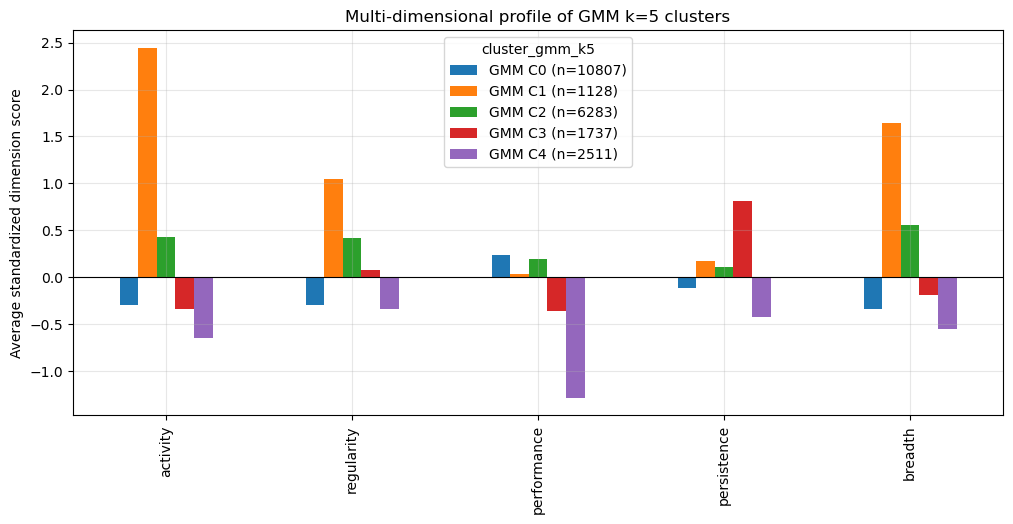

In [102]:
profile_plot_gmm = profile_summary_gmm_k5[profile_dims].copy()

rename_map = {
    cluster_id: f"GMM C{cluster_id} (n={int(profile_summary_gmm_k5.loc[cluster_id, 'n_users'])})"
    for cluster_id in profile_summary_gmm_k5.index
}

profile_plot_gmm = profile_plot_gmm.rename(index=rename_map)

profile_plot_gmm.T.plot(kind="bar", figsize=(12, 5))

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Average standardized dimension score")
plt.title("Multi-dimensional profile of GMM k=5 clusters")
plt.grid(alpha=0.3)
plt.show()

### Interpretation of GMM k=5

The Gaussian Mixture Model gives profiles that are broadly consistent with the K-Means k=5 solution.

- **GMM Cluster 0** corresponds to low-activity users with slightly above-average performance but below-average activity, regularity, persistence, and breadth. Its early dropout rate is 43.3%.

- **GMM Cluster 1** corresponds to highly engaged broad users. It has the strongest activity, regularity, and breadth scores, and one of the lowest early dropout rates, 25.4%.

- **GMM Cluster 2** corresponds to moderately engaged users, with above-average activity, regularity, performance, persistence, and breadth. Its early dropout rate is 32.9%.

- **GMM Cluster 3** corresponds to persistent users: activity and breadth are below average, but persistence is strongly above average. Its early dropout rate is 34.4%.

- **GMM Cluster 4** corresponds to low-activity struggling users. It is below average on all dimensions, especially performance, and has the highest early dropout rate, 47.0%.

Overall, the GMM profiles are very similar to the K-Means k=5 profiles. This suggests that the main behavioral profiles are not only an artifact of K-Means.

## Alternative clustering method: Agglomerative Clustering

Agglomerative clustering is a hierarchical method. Since it can be expensive on the full dataset, we test it on a random sample of users. This is used as a robustness check rather than as the main result.

In [108]:
from sklearn.cluster import AgglomerativeClustering
from tqdm.auto import tqdm
import threading
import time

agglo_full_k5 = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward",
)

result = {}

def run_agglo():
    result["labels"] = agglo_full_k5.fit_predict(X_behav_processed)

thread = threading.Thread(target=run_agglo)
thread.start()

with tqdm(desc="Running full AgglomerativeClustering", unit="s") as pbar:
    while thread.is_alive():
        time.sleep(1)
        pbar.update(1)

thread.join()

df["cluster_agglo_full_k5"] = result["labels"]

df["cluster_agglo_full_k5"].value_counts().sort_index()

c:\Users\loicm\miniconda3\envs\dl-gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Running full AgglomerativeClustering: 4s [00:17,  4.28s/s]


cluster_agglo_full_k5
0    16065
1     1895
2     1747
3     2273
4      486
Name: count, dtype: int64

In [109]:
cluster_agglo_full_k5_overview = (
    df.groupby("cluster_agglo_full_k5")
    .agg(
        n_users=("user_id", "count"),
        continuation_rate=("came_back", "mean"),
    )
    .reset_index()
)

cluster_agglo_full_k5_overview["early_dropout_rate"] = (
    1 - cluster_agglo_full_k5_overview["continuation_rate"]
)

cluster_agglo_full_k5_overview["percentage_users"] = (
    cluster_agglo_full_k5_overview["n_users"] / len(df)
)

cluster_agglo_full_k5_overview.round(3)

,cluster_agglo_full_k5,n_users,continuation_rate,early_dropout_rate,percentage_users
0,0,16065,0.579,0.421,0.715
1,1,1895,0.707,0.293,0.084
2,2,1747,0.539,0.461,0.078
3,3,2273,0.740,0.260,0.101
4,4,486,0.786,0.214,0.022


In [110]:
dimension_scores["cluster_agglo_full_k5"] = df["cluster_agglo_full_k5"]

profile_summary_agglo_full_k5 = (
    dimension_scores
    .groupby("cluster_agglo_full_k5")
    .agg(
        n_users=("user_id", "count"),
        continuation_rate=("came_back", "mean"),
        activity=("activity", "mean"),
        regularity=("regularity", "mean"),
        performance=("performance", "mean"),
        persistence=("persistence", "mean"),
        breadth=("breadth", "mean"),
    )
)

profile_summary_agglo_full_k5["early_dropout_rate"] = (
    1 - profile_summary_agglo_full_k5["continuation_rate"]
)

profile_summary_agglo_full_k5.round(3)

,n_users,continuation_rate,activity,regularity,performance,persistence,breadth,early_dropout_rate
cluster_agglo_full_k5,,,,,,,,
0,16065,0.579,-0.233,-0.144,0.149,-0.051,-0.217,0.421
1,1895,0.707,-0.083,0.120,0.080,0.776,0.056,0.293
2,1747,0.539,-0.649,-0.286,-1.767,-0.555,-0.536,0.461
3,2273,0.740,1.259,0.750,0.176,0.123,1.180,0.260
4,486,0.786,4.475,1.802,0.296,0.064,3.352,0.214


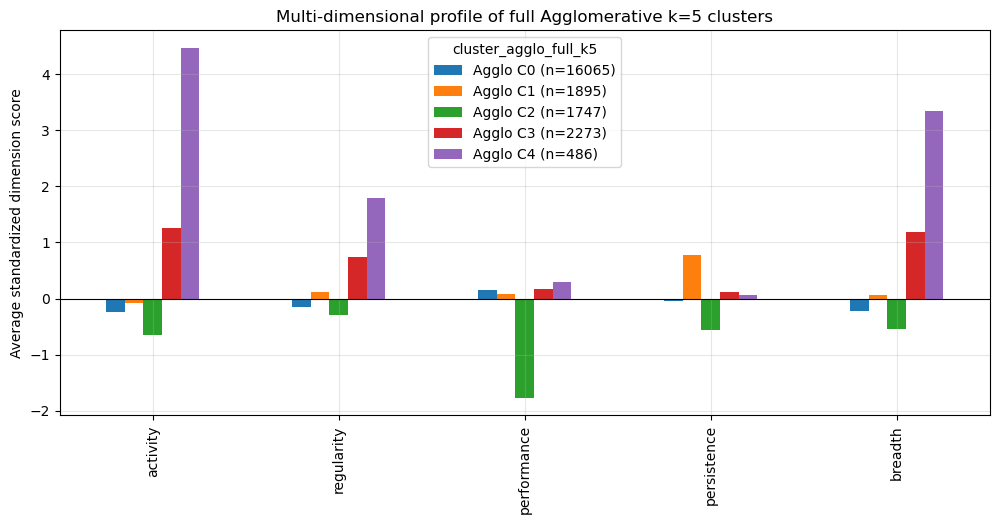

In [111]:
profile_plot_agglo_full = profile_summary_agglo_full_k5[profile_dims].copy()

rename_map = {
    cluster_id: f"Agglo C{cluster_id} (n={int(profile_summary_agglo_full_k5.loc[cluster_id, 'n_users'])})"
    for cluster_id in profile_summary_agglo_full_k5.index
}

profile_plot_agglo_full = profile_plot_agglo_full.rename(index=rename_map)

profile_plot_agglo_full.T.plot(kind="bar", figsize=(12, 5))

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Average standardized dimension score")
plt.title("Multi-dimensional profile of full Agglomerative k=5 clusters")
plt.grid(alpha=0.3)
plt.show()

### Interpretation of full Agglomerative k=5

The full Agglomerative clustering gives profiles that are very consistent with the K-Means and GMM results.

- **Cluster 0: Low activity but decent performance**  
  This is the largest group. Users are below average in activity, regularity, persistence, and breadth, but slightly above average in performance. Their early dropout rate is 42.1%.

- **Cluster 1: Persistent focused users**  
  These users are not especially high in activity or breadth, but they have a high persistence score. Their early dropout rate is 29.3%.

- **Cluster 2: Low activity struggling users**  
  This cluster is below average on all dimensions, especially performance. It has the highest early dropout rate, 46.1%.

- **Cluster 3: Moderately/highly engaged users**  
  These users are above average in activity, regularity, performance, persistence, and breadth. Their early dropout rate is 26.0%.

- **Cluster 4: Highly engaged broad users**  
  This is a small group with very high activity, regularity, and breadth. It has the lowest early dropout rate, 21.4%.

Overall, Agglomerative clustering recovers the same main behavioral profiles as K-Means and GMM. This supports the robustness of the learner profiles across different clustering algorithms.

## Comparison across clustering methods

Across K-Means, Gaussian Mixture Models, and Agglomerative clustering, we recover similar learner profiles:

1. **Low activity but decent performance users**
2. **Low activity struggling users**
3. **Persistent focused users**
4. **Moderately engaged users**
5. **Highly engaged broad users**

The exact cluster sizes differ across methods, but the qualitative structure is stable. In all methods, highly engaged and broad users have the lowest early dropout rates, while low-activity struggling users have the highest dropout rates.

This suggests that the profiles are not just an artifact of K-Means. They reflect stable behavioral patterns in the early Lernnavi usage data.

## Stage 2 temporal clustering idea

The Stage 1 clustering identifies early learner profiles from aggregated features. However, it does not model how behavior evolves over time.

Stage 2 is better suited for temporal clustering because it contains weekly user behavior and interruption labels. A natural extension is to cluster user-week observations into behavioral states, then analyze how users transition between states before an interruption.

# Stage 2 trajectory clustering

This section is closer to temporally coherent clustering.

Instead of clustering users from aggregated Stage 1 features, we use Stage 2 weekly data and build 12-week behavior trajectories.

Each sample corresponds to the previous 12 weeks of behavior for a user. We then cluster these trajectories to identify temporal behavior profiles, such as consistently low activity, increasing engagement, persistent activity, or decreasing engagement before interruption.

This is closer to Klingler et al. because the temporal order of behavior is preserved.

(30929, 6)
   user_id   gender   canton          class_level  study class_id
0   387604  Unknown  Unknown              Unknown  False  Unknown
1   387605  Unknown  Unknown              Unknown  False  Unknown
2   387608  Unknown  Unknown              Unknown   True    9Q2M7
3   387613  Unknown  Unknown              Unknown  False  Unknown
4   387615     MALE       SG  Gymnasium - 3. Jahr  False  Unknown
user_id        0
gender         0
canton         0
class_level    0
study          0
class_id       0
dtype: int64
action
PAGE_VISIT              2113982
REVIEW_TASK             1734632
SUBMIT_ANSWER           1404142
NAVIGATE_DASHBOARD      1093791
NEXT                     907521
WINDOW_VISIBLE_FALSE     851634
WINDOW_VISIBLE_TRUE      705679
VIEW_QUESTION            451981
OPEN_FEEDBACK            281632
CLOSE_FEEDBACK           251044
GO_TO_THEORY             211418
SUBMIT_SEARCH            162067
VIEW_SESSION_END         159925
SKIP                     158420
WINDOW_OPEN            

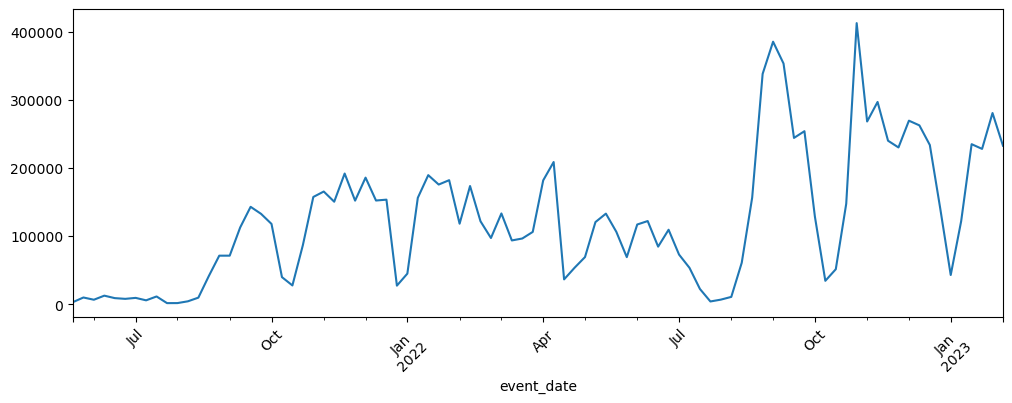

(30929, 61)
   user_id   gender   canton          class_level  study class_id  n_events  \
0   387604  Unknown  Unknown              Unknown  False  Unknown    5087.0   
1   387605  Unknown  Unknown              Unknown  False  Unknown    3604.0   
2   387608  Unknown  Unknown              Unknown   True    9Q2M7    2359.0   
3   387613  Unknown  Unknown              Unknown  False  Unknown     213.0   
4   387615     MALE       SG  Gymnasium - 3. Jahr  False  Unknown     535.0   

   n_active_days  n_active_weeks             first_event  ...  \
0          100.0            54.0 2021-05-22 05:12:11.416  ...   
1           54.0            33.0 2021-05-27 06:46:53.301  ...   
2           87.0            47.0 2021-09-05 08:29:42.198  ...   
3            5.0             4.0 2021-07-28 07:55:26.135  ...   
4           12.0             9.0 2021-08-28 13:14:30.684  ...   

  avg_response_time  median_response_time  n_challenges  has_events  \
0         53.863150               18.2290          

In [116]:
%run preprocess_new_features.ipynb

In [120]:
import sys
import importlib
from pathlib import Path

PROJECT_DIR = Path(
    r"c:/Users/loicm/Documents/EPFL/2025-2026/MA4/ML_for_BD/CS-421-Project-learnavi"
)

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

preprocess_module = importlib.import_module("preprocess")

print(preprocess_module)
print(preprocess_module.preprocess)

<module 'preprocess' from 'c:\\Users\\loicm\\Documents\\EPFL\\2025-2026\\MA4\\ML_for_BD\\CS-421-Project-learnavi\\preprocess.py'>
<function preprocess at 0x000001F53F7C5480>


In [121]:
DATA_DIR = PROJECT_DIR / "data"

users_clean, events_clean, transactions_clean, event_users_features, feature_cols, df_full = (
    preprocess_module.preprocess(DATA_DIR)
)

print("df_full shape:", df_full.shape)
print("Number of feature columns:", len(feature_cols))
print(feature_cols)

df_full.head()

df_full shape: (408377, 24)
Number of feature columns: 17
['n_events', 'n_active_days', 'mean_hour', 'n_click_events', 'n_view_events', 'n_sessions', 'n_topics_event', 'n_transactions', 'correct_rate', 'partial_rate', 'mean_evaluation_score', 'avg_response_time', 'n_topics_transaction', 'n_documents', 'activity_score', 'year', 'day']


,user_id,relative_week,n_events,n_active_days,mean_hour,n_click_events,n_view_events,n_sessions,n_topics_event,n_transactions,...,n_documents,n_topics_transaction,activity_score,first_event,week_start,is_active,is_dropout_point,year,day,is_summer
0,387604,0,2.0,2.0,9.0,0.0,2.0,0.0,0.0,2.0,...,1.0,0.0,6.0,2021-05-22 05:12:11.416,2021-05-22 05:12:11.416,1,0.0,2021,142,False
1,387604,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2021-05-22 05:12:11.416,2021-05-29 05:12:11.416,0,0.0,2021,149,False
2,387604,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2021-05-22 05:12:11.416,2021-06-05 05:12:11.416,0,0.0,2021,156,False
3,387604,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2021-05-22 05:12:11.416,2021-06-12 05:12:11.416,0,0.0,2021,163,False
4,387604,4,7.0,1.0,8.0,4.0,3.0,1.0,1.0,0.0,...,0.0,0.0,14.0,2021-05-22 05:12:11.416,2021-06-19 05:12:11.416,1,0.0,2021,170,False


In [122]:
stage2_df = df_full.copy()

ID_COL = "user_id"
TIME_COL = "relative_week"
LABEL_COL = "is_dropout_point"

# We remove calendar features because we want behavioral trajectories,
# not clusters driven by year/day seasonality.
stage2_behavior_features = [
    c for c in feature_cols
    if c not in ["year", "day"]
]

print("Behavior features:", len(stage2_behavior_features))
print(stage2_behavior_features)

assert ID_COL in stage2_df.columns
assert TIME_COL in stage2_df.columns
assert LABEL_COL in stage2_df.columns

Behavior features: 15
['n_events', 'n_active_days', 'mean_hour', 'n_click_events', 'n_view_events', 'n_sessions', 'n_topics_event', 'n_transactions', 'correct_rate', 'partial_rate', 'mean_evaluation_score', 'avg_response_time', 'n_topics_transaction', 'n_documents', 'activity_score']


In [123]:
stage2_df = stage2_df.sort_values([ID_COL, TIME_COL]).copy()

# Keep only rows where the future interruption label is known
stage2_df = stage2_df.dropna(subset=[LABEL_COL]).copy()
stage2_df[LABEL_COL] = stage2_df[LABEL_COL].astype(int)

print("Stage2 rows:", stage2_df.shape)
print("Users:", stage2_df[ID_COL].nunique())
print("Dropout point distribution:")
print(stage2_df[LABEL_COL].value_counts(normalize=True).round(3))

Stage2 rows: (342844, 24)
Users: 13032
Dropout point distribution:
is_dropout_point
1    0.506
0    0.494
Name: proportion, dtype: float64


In [124]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

weekly_preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

weekly_scaled = weekly_preprocess.fit_transform(stage2_df[stage2_behavior_features])

weekly_scaled_df = pd.DataFrame(
    weekly_scaled,
    columns=stage2_behavior_features,
    index=stage2_df.index,
)

weekly_scaled_df.head()

,n_events,n_active_days,mean_hour,n_click_events,n_view_events,n_sessions,n_topics_event,n_transactions,correct_rate,partial_rate,mean_evaluation_score,avg_response_time,n_topics_transaction,n_documents,activity_score
0,-0.210129,2.408444,1.659319,-0.209227,-0.203559,-0.188340,-0.239813,-0.060834,-0.300574,-0.275512,-0.335501,-0.2327,-0.225825,-0.145685,-0.198666
1,-0.232913,-0.358804,-0.412726,-0.209227,-0.242171,-0.188340,-0.239813,-0.121449,-0.300574,-0.275512,-0.335501,-0.2327,-0.225825,-0.231863,-0.229310
2,-0.232913,-0.358804,-0.412726,-0.209227,-0.242171,-0.188340,-0.239813,-0.121449,-0.300574,-0.275512,-0.335501,-0.2327,-0.225825,-0.231863,-0.229310
3,-0.232913,-0.358804,-0.412726,-0.209227,-0.242171,-0.188340,-0.239813,-0.121449,-0.300574,-0.275512,-0.335501,-0.2327,-0.225825,-0.231863,-0.229310
4,-0.153170,1.024820,1.429092,-0.103311,-0.184253,0.203062,0.785253,-0.121449,-0.300574,-0.275512,-0.335501,-0.2327,-0.225825,-0.231863,-0.157807


In [126]:
SEQUENCE_LENGTH = 12

# Make sure data is sorted
stage2_df = stage2_df.sort_values([ID_COL, TIME_COL]).copy()

# NumPy arrays for speed
X_weekly = weekly_scaled_df[stage2_behavior_features].to_numpy()
y_all = stage2_df[LABEL_COL].to_numpy()
users_all = stage2_df[ID_COL].to_numpy()
weeks_all = stage2_df[TIME_COL].to_numpy()
index_all = stage2_df.index.to_numpy()

X_sequences = []
y_sequences = []
user_ids = []
end_weeks = []
row_indices = []

# groupby indices instead of slicing dataframes repeatedly
for user_id, user_idx in stage2_df.groupby(ID_COL).indices.items():
    user_idx = np.array(user_idx)

    if len(user_idx) < SEQUENCE_LENGTH:
        continue

    # because stage2_df is sorted, user_idx is already in temporal order
    for end_pos in range(SEQUENCE_LENGTH - 1, len(user_idx)):
        seq_positions = user_idx[end_pos - SEQUENCE_LENGTH + 1 : end_pos + 1]
        end_position = user_idx[end_pos]

        X_sequences.append(X_weekly[seq_positions])
        y_sequences.append(int(y_all[end_position]))
        user_ids.append(user_id)
        end_weeks.append(weeks_all[end_position])
        row_indices.append(index_all[end_position])

X_sequences = np.asarray(X_sequences)
y_sequences = np.asarray(y_sequences)
user_ids = np.asarray(user_ids)
end_weeks = np.asarray(end_weeks)
row_indices = np.asarray(row_indices)

print("X_sequences shape:", X_sequences.shape)
print("y_sequences shape:", y_sequences.shape)
print("Interruption rate:", y_sequences.mean().round(3))

X_sequences shape: (222739, 12, 15)
y_sequences shape: (222739,)
Interruption rate: 0.497


In [127]:
n_samples, seq_len, n_features = X_sequences.shape

X_traj_flat = X_sequences.reshape(n_samples, seq_len * n_features)

print("Original sequence shape:", X_sequences.shape)
print("Flattened trajectory shape:", X_traj_flat.shape)

Original sequence shape: (222739, 12, 15)
Flattened trajectory shape: (222739, 180)


In [128]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

trajectory_silhouette_results = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
    )

    labels = model.fit_predict(X_traj_flat)

    score = silhouette_score(
        X_traj_flat,
        labels,
        sample_size=min(5000, X_traj_flat.shape[0]),
        random_state=RANDOM_STATE,
    )

    trajectory_silhouette_results.append({
        "k": k,
        "silhouette": score,
    })

    print(f"k={k}, silhouette={score:.4f}")

trajectory_silhouette_df = pd.DataFrame(trajectory_silhouette_results)
trajectory_silhouette_df

k=2, silhouette=0.6578
k=3, silhouette=0.4854
k=4, silhouette=0.4710
k=5, silhouette=0.4801
k=6, silhouette=0.4742
k=7, silhouette=0.4552
k=8, silhouette=0.4580


,k,silhouette
0,2,0.657762
1,3,0.485353
2,4,0.470957
3,5,0.480103
4,6,0.474242
5,7,0.455207
6,8,0.458005


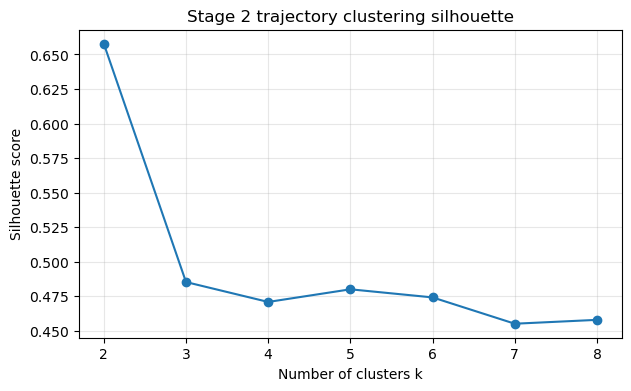

In [129]:
plt.figure(figsize=(7, 4))
plt.plot(
    trajectory_silhouette_df["k"],
    trajectory_silhouette_df["silhouette"],
    marker="o",
)
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Stage 2 trajectory clustering silhouette")
plt.grid(alpha=0.3)
plt.show()

In [130]:
TRAJ_K = 5

kmeans_traj = KMeans(
    n_clusters=TRAJ_K,
    random_state=RANDOM_STATE,
    n_init=10,
)

trajectory_clusters = kmeans_traj.fit_predict(X_traj_flat)

traj_df = pd.DataFrame({
    ID_COL: user_ids,
    "end_week": end_weeks,
    "row_index": row_indices,
    "trajectory_cluster": trajectory_clusters,
    LABEL_COL: y_sequences,
})

traj_df.head()

,user_id,end_week,row_index,trajectory_cluster,is_dropout_point
0,387604,11,11,0,0
1,387604,12,12,4,0
2,387604,13,13,4,0
3,387604,14,14,4,0
4,387604,15,15,4,0


In [131]:
traj_overview = (
    traj_df.groupby("trajectory_cluster")
    .agg(
        n_sequences=(ID_COL, "count"),
        n_users=(ID_COL, "nunique"),
        interruption_rate=(LABEL_COL, "mean"),
    )
    .reset_index()
)

traj_overview["percentage_sequences"] = traj_overview["n_sequences"] / len(traj_df)

traj_overview.round(3)

,trajectory_cluster,n_sequences,n_users,interruption_rate,percentage_sequences
0,0,165019,7501,0.528,0.741
1,1,19377,7650,0.490,0.087
2,2,4098,1384,0.314,0.018
3,3,3996,688,0.234,0.018
4,4,30249,3696,0.393,0.136


In [132]:
trajectory_feature_groups = {
    "activity": [
        "n_events",
        "n_click_events",
        "n_view_events",
        "n_transactions",
        "n_documents",
        "n_sessions",
        "activity_score",
    ],
    "regularity": [
        "n_active_days",
        "mean_hour",
    ],
    "performance": [
        "correct_rate",
        "partial_rate",
        "mean_evaluation_score",
        "avg_response_time",
    ],
    "breadth": [
        "n_topics_event",
        "n_topics_transaction",
    ],
}

trajectory_feature_groups = {
    group: [c for c in cols if c in stage2_behavior_features]
    for group, cols in trajectory_feature_groups.items()
}

trajectory_feature_groups

{'activity': ['n_events',
  'n_click_events',
  'n_view_events',
  'n_transactions',
  'n_documents',
  'n_sessions',
  'activity_score'],
 'regularity': ['n_active_days', 'mean_hour'],
 'performance': ['correct_rate',
  'partial_rate',
  'mean_evaluation_score',
  'avg_response_time'],
 'breadth': ['n_topics_event', 'n_topics_transaction']}

In [133]:
dimension_weekly = {}

for group_name, cols in trajectory_feature_groups.items():
    if len(cols) == 0:
        continue

    col_indices = [stage2_behavior_features.index(c) for c in cols]

    # shape: (n_sequences, 12)
    dimension_weekly[group_name] = X_sequences[:, :, col_indices].mean(axis=2)

dimension_weekly.keys()

dict_keys(['activity', 'regularity', 'performance', 'breadth'])

In [134]:
traj_dimension_summary = traj_df.copy()

for dim, values in dimension_weekly.items():
    traj_dimension_summary[f"{dim}_mean"] = values.mean(axis=1)
    traj_dimension_summary[f"{dim}_start"] = values[:, 0]
    traj_dimension_summary[f"{dim}_end"] = values[:, -1]
    traj_dimension_summary[f"{dim}_change"] = values[:, -1] - values[:, 0]

summary_cols = []

for dim in dimension_weekly.keys():
    summary_cols += [
        f"{dim}_mean",
        f"{dim}_start",
        f"{dim}_end",
        f"{dim}_change",
    ]

traj_profile_summary = (
    traj_dimension_summary
    .groupby("trajectory_cluster")
    .agg(
        n_sequences=(ID_COL, "count"),
        n_users=(ID_COL, "nunique"),
        interruption_rate=(LABEL_COL, "mean"),
        **{col: (col, "mean") for col in summary_cols}
    )
)

traj_profile_summary.round(3)

,n_sequences,n_users,interruption_rate,activity_mean,activity_start,activity_end,activity_change,regularity_mean,regularity_start,regularity_end,regularity_change,performance_mean,performance_start,performance_end,performance_change,breadth_mean,breadth_start,breadth_end,breadth_change
trajectory_cluster,,,,,,,,,,,,,,,,,,,
0,165019,7501,0.528,-0.182,-0.199,-0.178,0.021,-0.296,-0.306,-0.287,0.019,-0.236,-0.275,-0.227,0.048,-0.199,-0.218,-0.194,0.024
1,19377,7650,0.490,0.058,1.471,-0.083,-1.553,0.156,2.109,-0.094,-2.203,0.145,2.100,-0.050,-2.150,0.076,1.722,-0.096,-1.818
2,4098,1384,0.314,1.041,1.390,0.338,-1.052,0.948,1.341,0.504,-0.836,0.623,0.950,0.361,-0.590,0.863,1.153,0.205,-0.948
3,3996,688,0.234,1.471,0.934,1.168,0.234,1.285,1.002,1.094,0.092,0.878,0.770,0.741,-0.029,1.175,0.687,0.876,0.189
4,30249,3696,0.393,0.131,-0.150,0.202,0.353,0.352,-0.103,0.389,0.491,0.285,-0.167,0.323,0.490,0.147,-0.166,0.204,0.371


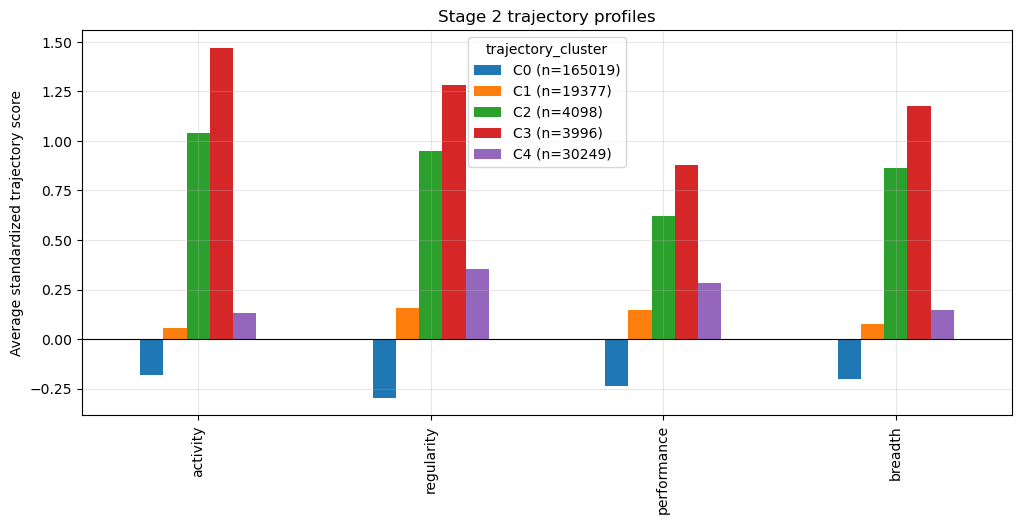

In [135]:
mean_dim_cols = [f"{dim}_mean" for dim in dimension_weekly.keys()]

plot_df = traj_profile_summary[mean_dim_cols].copy()
plot_df.columns = [c.replace("_mean", "") for c in plot_df.columns]

rename_map = {
    cluster_id: f"C{cluster_id} (n={int(traj_profile_summary.loc[cluster_id, 'n_sequences'])})"
    for cluster_id in traj_profile_summary.index
}

plot_df = plot_df.rename(index=rename_map)

plot_df.T.plot(kind="bar", figsize=(12, 5))

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Average standardized trajectory score")
plt.title("Stage 2 trajectory profiles")
plt.grid(alpha=0.3)
plt.show()

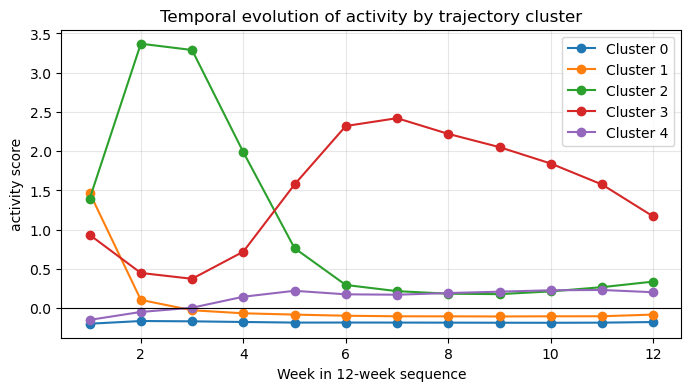

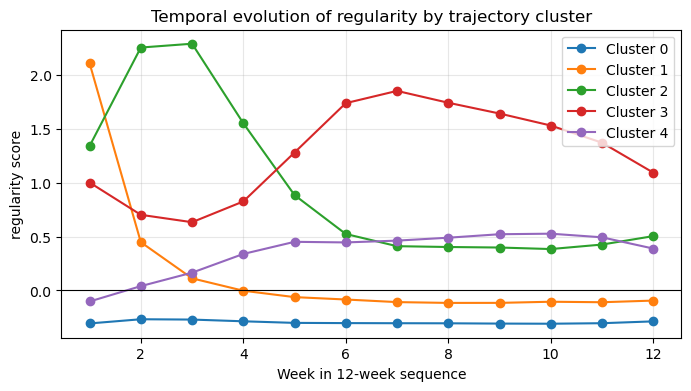

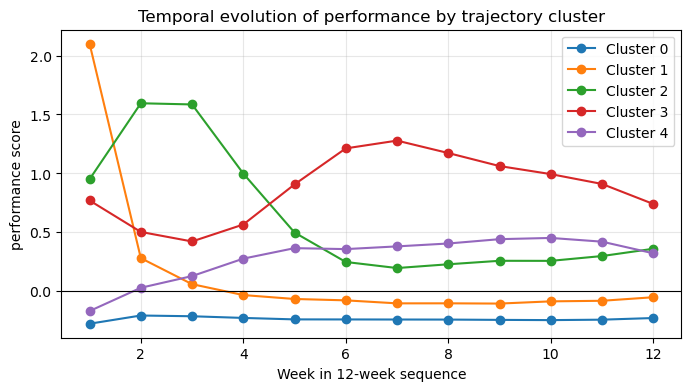

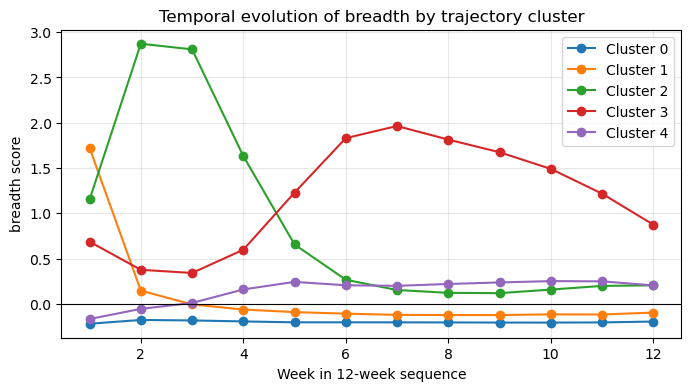

In [136]:
for dim, values in dimension_weekly.items():
    plt.figure(figsize=(8, 4))

    for cluster_id in sorted(traj_df["trajectory_cluster"].unique()):
        mask = traj_df["trajectory_cluster"].values == cluster_id
        mean_curve = values[mask].mean(axis=0)

        plt.plot(
            range(1, SEQUENCE_LENGTH + 1),
            mean_curve,
            marker="o",
            label=f"Cluster {cluster_id}",
        )

    plt.axhline(0, color="black", linewidth=0.8)
    plt.xlabel("Week in 12-week sequence")
    plt.ylabel(f"{dim} score")
    plt.title(f"Temporal evolution of {dim} by trajectory cluster")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

### Interpretation of Stage 2 trajectory clusters

The Stage 2 trajectory clustering identifies five temporal behavior profiles over 12-week sequences.

- **Cluster 0: Consistently low activity trajectories**  
  This is the largest cluster, representing 74.1% of sequences. It stays below average in activity, regularity, performance, and breadth throughout the 12-week window. It has the highest interruption rate, 52.8%.

- **Cluster 1: Early spike then drop-off**  
  This cluster starts with very high activity, regularity, performance, and breadth, but all dimensions sharply decrease by the end of the sequence. Its interruption rate is 49.0%, showing that an initial spike of engagement is not sufficient if it is followed by rapid disengagement.

- **Cluster 2: Early high engagement then decay**  
  This cluster is highly engaged on average, but shows a gradual decline over time. Unlike Cluster 1, it remains above average at the end of the sequence. Its interruption rate is lower, 31.4%.

- **Cluster 3: Sustained high engagement trajectories**  
  This cluster has consistently high activity, regularity, performance, and breadth, and remains high until the end of the sequence. It has the lowest interruption rate, 23.4%.

- **Cluster 4: Increasing moderate engagement**  
  This cluster starts slightly below average but improves across all dimensions over time. Its interruption rate is intermediate, 39.3%.

Overall, the interruption risk is highest for consistently low trajectories and for trajectories with a strong early drop-off. In contrast, sustained high engagement and maintained above-average behavior are associated with lower interruption rates.